# Libraries

In [21]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np

# Dataset

### $R$ and $S$ realization

In [22]:
n_samples = 1
n_latent_samples = 5000
time = [0., 10., 20., 30., 40., 50., 60., 70., 80., 90., 100.]
r   = Normal(loc = 5., scale=0.8)
s   = Normal(loc = 2., scale=0.6)
joint = JointIndependent(marginals=[r, s])
x = joint.rvs(n_samples)
x

array([[4.672019  , 1.05713627]])

### $g$ over the time

In [23]:
lambdas = []
gs = []
for k in time:
    y, df = state_limit_function_time(x, n_latent_samples, t=k)
    lambdas.append(y)
    gs.append(df[0])

In [24]:
lambdas = np.vstack(lambdas)
lambdas

array([[ 3.6241429 ,  8.78249084,  0.12778394,  0.14186033],
       [ 3.29086103,  9.14492387,  0.13186491,  0.13769835],
       [ 2.96470868,  9.72757567,  0.11158871,  0.1367057 ],
       [ 2.63895858, 10.19347548,  0.11594212,  0.14922302],
       [ 2.31325748, 10.90185529,  0.10181629,  0.13375416],
       [ 1.98589093, 10.79263878,  0.11923489,  0.18835851],
       [ 1.6588036 , 11.64568839,  0.10411834,  0.15936849],
       [ 1.33117194, 12.32467983,  0.08975352,  0.15106989],
       [ 1.00544487, 12.42332539,  0.11325378,  0.16951906],
       [ 0.67843436, 12.84599337,  0.11504035,  0.1723139 ],
       [ 0.34967768, 13.46126526,  0.09735942,  0.19649826]])

# Chart

### $g$ over the time

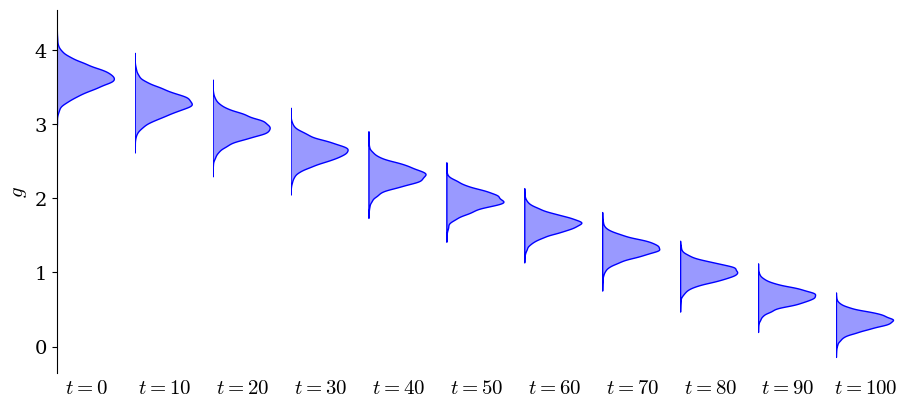

In [25]:
### Figure name and DPI
dpi = 600
name = 'time-lapse_g_analysis'

### Chart dimensions
b_cm_individual = 2.5      
h_cm = 12                 
inches_to_cm = 1 / 2.54

n_plots = len(time) 
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_y = '$g$'
size_label = 15
color_label = 'black'
size_axis = 14
color_axis = 'black'
color = 'blue'
alpha = 0.4

### Figure
fig, axes = plt.subplots(nrows=1, ncols=n_plots, sharey=True, figsize=(b_input_total, h_input))

### Space between plots
plt.subplots_adjust(wspace=0.3) 

### Loop
for i, ax in enumerate(axes):
    
    ### Plot
    current_data = gs[i]
    sns.kdeplot(y=current_data['g'], fill=True, alpha=alpha, ax=ax, color=color)
    
    # Configurações gerais (Fonte, Cor)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label X
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label, color=color_label)
    
    # Remove ticks e números do eixo X (como você pediu antes)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Remove bordas padrão (Topo, Direita, Baixo)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- AQUI ESTÁ A MÁGICA PARA REMOVER O EIXO Y DOS OUTROS ---
    if i == 0:
        # Primeiro gráfico: Mantém a linha da esquerda e o Label Y
        ax.spines['left'].set_visible(True)
        ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
    else:
        # Do segundo em diante:
        ax.spines['left'].set_visible(False)   # Remove a linha vertical
        ax.tick_params(axis='y', left=False)   # Remove os tracinhos (ticks) da esquerda
        ax.set_ylabel('')                      # Remove o label
        
### Save and Show
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### $\lambda$ over the time

In [26]:
x = time.copy()
y1 = lambdas[:,0]
y2 = lambdas[:,1]
y3 = lambdas[:,2]
y4 = lambdas[:,3]
data = [
        {'x': x, 'y': y1},
        {'x': x, 'y': y2},
        {'x': x, 'y': y3},
        {'x': x, 'y': y4}
    ]

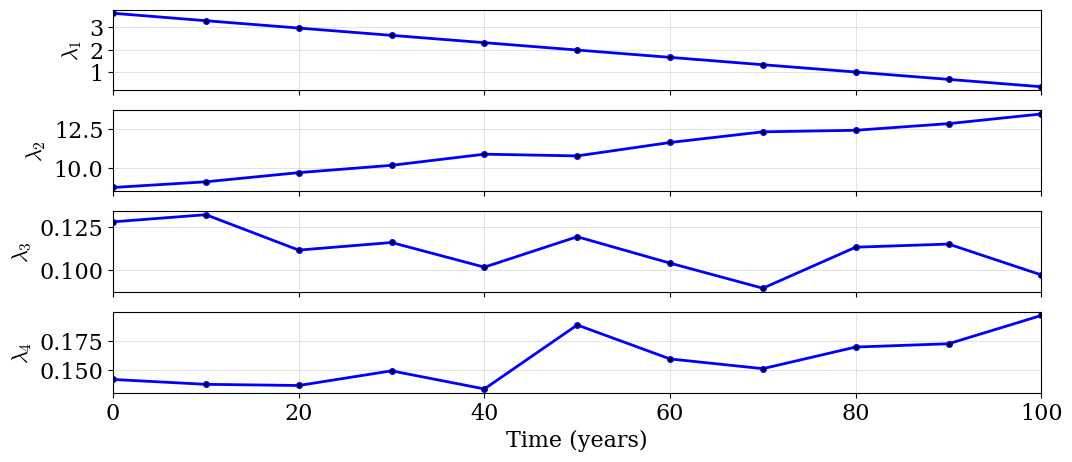

In [27]:
### Figure name and DPI
dpi = 600
name = 'lambdas_for_r_s_realization'

### Axis and labels
label_x = 'Time (years)'  
size_label = 16
color_label = 'black'
size_axis = 16
color_axis = 'black'

### Line
size_line = 2
style_line = '-'
color_line = 'blue'

### Marker
marker = 'o'
size_marker = 4
color_marker = 'black'
color_marker_edge = color_line

### Legend
labels_legend = ['$\lambda _1$', '$\lambda _2$', '$\lambda _3$', '$\lambda _4$']  # Change as you wish
size_legend = 18
location_legend = 'upper right'

### Grid
on_or_off = False
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(b_input_total, h_input))

### Plot
i = 0
for ax, dataset in zip(axes, data):
    
    ax.plot(dataset['x'], dataset['y'],
            markerfacecolor=color_marker, marker=marker, markersize=size_marker,
            linewidth=size_line, linestyle=style_line, color=color_line)
    
    # Configuração dos Eixos (Cores e Tamanhos)
    ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
    
    # Label Y (Específico de cada gráfico, mas com seu estilo)
    ax.set_ylabel(labels_legend[i], fontsize=size_label, color=color_label)
    i += 1
    
    # Configuração do Grid
    ax.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)
    
    # # Legenda
    # ax.legend(fontsize=size_legend, loc=location_legend)

# Ajuste específico para a Tangente (índice 2) pois ela vai ao infinito
# axes[2].set_ylim(-3, 3)
axes[0].set_xlim(0, 100)
axes[1].set_xlim(0, 100)
axes[2].set_xlim(0, 100)
axes[3].set_xlim(0, 100)

# Label X apenas no último gráfico
axes[-1].set_xlabel(label_x, fontsize=size_label, color=color_label)

# Ajustar espaçamento
plt.tight_layout()

# --- 6. SALVAR E MOSTRAR ---
fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()

### Ground truth versus GLAM

#### Ground Truth t = 50 years

In [28]:
gt_data = list(gs[5]['g'])

#### PCE t = 50 years

In [34]:
lambda_3 = list(lambdas[:,2])
lambda_3 = np.mean(lambda_3)
lambda_3

0.11161420745051043

In [29]:
lambdas_aux = list(lambdas[5,:])

def glam_generator(lambdas, n_points=5000, quantile_trim=1e-3, qp_min=1e-8, ylim=None):
    l1, l2, l3, l4 = lambdas

    # Curva da PDF GLD (robusta para evitar explosões numéricas)
    a = float(quantile_trim)
    u = np.linspace(a, 1.0 - a, n_points)
    x = gld_fkml_quantile(u, l1, l2, l3, l4)
    qp = gld_fkml_qprime(u, l2, l3, l4)

    mask = np.isfinite(x) & np.isfinite(qp) & (qp > qp_min)
    x, f = x[mask], (1.0 / qp[mask])

    order = np.argsort(x)
    x, f = x[order], f[order]

    return list(x), list(f)

glam_data, _ = glam_generator(lambdas_aux) 

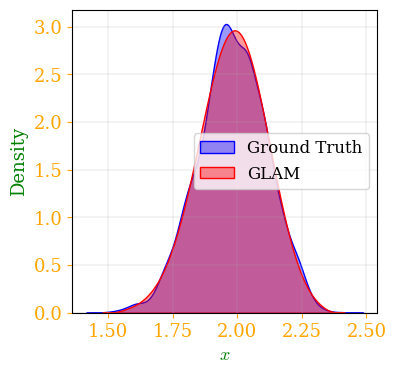

In [30]:
### Figure name and DPI
dpi = 600                                                                               # Change as you wish
name = 'kde_histogram_compare_glam_versus_gt' # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 10                                                   # Change as you wish
h_cm = 10                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_y = 'Density'
label_x = '$x$'                     # Change as you wish     
size_label = 13                     # Change as you wish
color_label = 'green'               # or hexadecimal. Change as you wish
size_axis = 13                      # Change as you wish
color_axis = 'orange'                # or hexadecimal. Change as you wish

### Color KDE
color = ['blue', 'red']             # or hexadecimal. Change as you wish
alpha = 0.4                         # Change as you wish

### Legend. Do you need legend? Use the cell bellow:
legend_label = ['Ground Truth', 'GLAM']    # Change as you wish
size_legend = 12                       # Change as you wish
location_legend = 'center right'       # Change as you wish

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

### Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)

### Plot with legend
sns.kdeplot(data=gt_data, fill=True, alpha=alpha, ax=ax, color=color[0], label=legend_label[0])
sns.kdeplot(data=glam_data, fill=True, alpha=alpha, ax=ax, color=color[1], label=legend_label[1])
### Legend. Do you need legend? Use the cell bellow:
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()